<a href="https://colab.research.google.com/github/pavam123/Capstone-project-of-Hotel-Booking-Analysis/blob/main/DeepFER_Facial_Emotion_Recognition_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name:**           **DeepFER: Facial Emotion Recognition Using Deep Learning**


# **Project Type: Deep Learning for Computer Vision**
# **Name: CH.PAVAN KUMAR**

# **GIT HUB:**

# **OVERVIEW:**
**DeepFER:** Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

# **Dataset Overview**
**Dataset Composition:**
Contains images categorized into seven distinct emotion classes: angry, sad, happy, fear, neutral, disgust, and surprise.

# **Emotion Classes:**

**Angry:** Images depicting expressions of anger.

**Sad:** Images depicting expressions of sadness.

**Happy:** Images depicting expressions of happiness.

**Fear:** Images depicting expressions of fear.

**Neutral:** Images depicting neutral, non-expressive faces.

**Disgust:** Images depicting expressions of disgust.

**Surprise:** Images depicting expressions of surprise.

# **Image Characteristics:**
High-quality facial images with diverse backgrounds and lighting conditions.
Includes both posed and spontaneous expressions to ensure robustness.

# **Data Augmentation:**
Techniques such as rotation, scaling, and flipping applied to increase dataset variability and enhance model generalization.

# **Dataset Annotations:**
Each image is labeled with its corresponding emotion class.

# **Data Source:**
Collected from publicly available facial expression databases and crowd-sourced contributions.

# **Usage:**
Used for training, validation, and testing phases in the emotion recognition model development.

# **Purpose:**
To train and evaluate the DeepFER model for accurate and real-time facial emotion recognition across diverse scenarios.

# **Project Goal**
**The primary goal of DeepFER**: Facial Emotion Recognition Using Deep Learning is to develop an advanced and efficient system capable of accurately identifying and classifying human emotions from facial expressions in real-time. By leveraging state-of-the-art Convolutional Neural Networks (CNNs) and Transfer Learning techniques, this project aims to create a robust model that can handle the inherent variability in facial expressions and diverse image conditions. The system will be trained on a comprehensive dataset featuring seven distinct emotions: angry, sad, happy, fear, neutral, disgust, and surprise. The ultimate objective is to achieve high accuracy and reliability, making DeepFER suitable for applications in human-computer interaction, mental health monitoring, customer service, and beyond. Through this project, we aim to bridge the gap between cutting-edge AI research and practical emotion recognition applications, contributing to more empathetic and responsive machine interactions with humans.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Connects our google drive to the colab environment so you can load/save files directly from/to drive.

In [3]:
# Getting the Data-Set from dropbox
!wget https://www.dropbox.com/s/si11cws2pyho1bp/archive.zip

--2025-08-19 17:56:43--  https://www.dropbox.com/s/si11cws2pyho1bp/archive.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/x9eaye2fanuc005ucprmq/archive.zip?rlkey=fawlx24mxtnicc8f65kd5ufap [following]
--2025-08-19 17:56:43--  https://www.dropbox.com/scl/fi/x9eaye2fanuc005ucprmq/archive.zip?rlkey=fawlx24mxtnicc8f65kd5ufap
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc303c86e8dcb3baf631fcad9696.dl.dropboxusercontent.com/cd/0/inline/CvuqtbBCzrguBwTDrk-dU3UL7Iw44MgLEnNM6LU12LeXrptnb5lsfAfq_Y0If_FgGk8ya0O0lXlPUXrSShw9V2l5co73auCprb3o3zSMvmgMkkzSy8qVFgEyYN4JLL8jGLxwUS6Cm48800ID_qu9wak_/file# [following]
--2025-08-19 17:56:43--  https://uc303c86e8dcb3baf631fcad9696.dl.dropboxusercontent.com/cd/0/inline/Cvuq



*   Uses the wget command to fetch the dataset zip file from Dropbox
*   saves it as archive.zip inside Colab




# **Dataset Overview**

**Dataset Composition:**
Contains images categorized into seven distinct emotion classes: angry, sad, happy, fear, neutral, disgust, and surprise.

In [4]:
# Unzipping the dataset
!unzip  -q "/content/archive.zip"



*   Extracts all files from the archive.zip archive into the current folder.

*   -q = quiet mode (does not print all file names)


In [5]:
# Importing Neccessary Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler



*   **Loads all packages required for:**

1.Deep Learning (tensorflow, keras)

2.Image handling (cv2)

3.Plotting (matplotlib)

4.Working with arrays (numpy)

5.Path manipulation (Path)

6.Data preprocessing (MinMaxScaler — though in this snippet we don’t use it directly later)  



In [6]:
# locating path and creating classes from dataset
trainpath=Path("/content/train")
Classes=[str(list(trainpath.glob("*"))[i]).split('/')[-1] for i in range(len(list(trainpath.glob("*"))))]
Classes

['disgust', 'sad', 'surprise', 'angry', 'neutral', 'fear', 'happy']


*   trainpath points to the training data folder.
*   Extracts a list of subfolder names (each subfolder = one emotion class).

*  Displays them.




# **Emotion Classes:**
**Angry:** Images depicting expressions of anger.

**Sad:** Images depicting expressions of sadness.

**Happy:** Images depicting expressions of happiness.

**Fear:** Images depicting expressions of fear.

**Neutral:** Images depicting neutral, non-expressive faces.

**Disgust:** Images depicting expressions of disgust.

**Surprise:** Images depicting expressions of surprise.

In [7]:

Classes =['sad', 'neutral', 'fear', 'happy', 'disgust', 'angry', 'surprise']



*   Hardcodes the class list in a specific order for consistent label mapping.




In [8]:
# Reading sample image from dataset
img_array=cv2.imread('/content/train/sad/Training_49187727.jpg')



*   Loads one image from the ‘sad’ class into a NumPy array.



In [9]:
# Checking the dimension of the image
img_array.shape

(48, 48, 3)



*   Prints dimensions.


*   Output: (48, 48, 3) → height=48px, width=48px, 3 color channels (RGB).




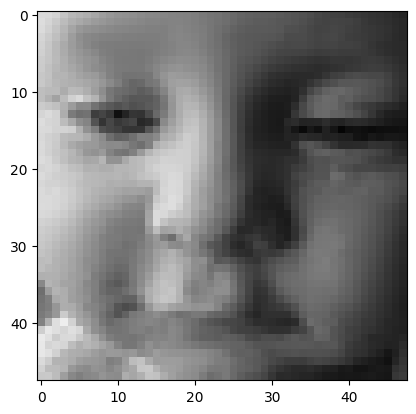

In [10]:

# displaying the image
plt.imshow(img_array)


Shows the raw image (note: OpenCV loads images in BGR format, so colors might look off here).


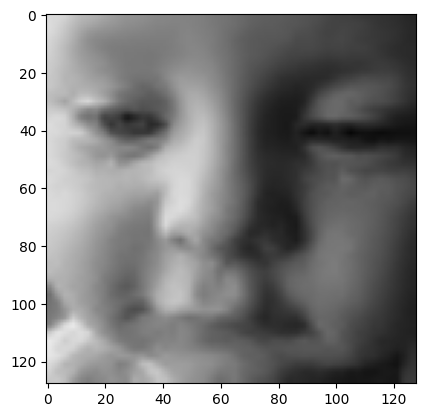

In [11]:
# resizing the image so to make compatible with input of mobilenetv2 model
img_size=128
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array,cv2.COLOR_BGR2RGB))
plt.show()

--Resizes the image to 128×128 pixels to match MobileNetV2 input requirements.

--Converts from BGR → RGB before displaying correctly.

--This step is needed for model compatibility.

In [12]:
# converting the path to string type
pathlist=list(map(lambda x: str(x), list(trainpath.glob("*/*"))))

Converts Path objects to strings for easy handling.

In [13]:
# loading the training data
training_data=[]
for path in pathlist:
  img_array=cv2.imread(path)
  new_array=cv2.resize(img_array,(img_size,img_size))
  Class_label=Classes.index(path.split('/')[-2])
  training_data.append([new_array,Class_label])

--Reads each image file.


--Resizes to 128×128.

--Finds the class label from the folder name using the Classes list.

--Saves [image_array, label] pairs to training_data.

In [14]:

# shuffling the data
import random
random.shuffle(training_data)
training_data=training_data[:2500]






*   Randomizes order of dataset.
*   Keeps only the first 2500 samples (for faster training in Colab).



In [15]:
ld=[]
for i in range(len(training_data)):
   ld.append(training_data[i][1])
np.unique(ld,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]), array([409, 458, 366, 608,  47, 355, 257]))



*  Extracts all labels and counts how many samples per class.


*   Helps check for imbalance.



In [16]:
# creating dependent and independent variable
X=[]
y=[]
for feature, label in training_data:
  X.append(feature)
  y.append(label)

Creates two separate lists:

X = image arrays

y = corresponding labels


In [17]:
# normalizing the data
X=np.array(X).reshape(-1,img_size,img_size,3)/255
y=np.array(y)



*   Converts X and y into NumPy arrays.


*   Normalizes pixel values to range [1] for better training stability.



In [18]:

# loading the mobilenetv2 model to apply transfer learning
model=tf.keras.applications.MobileNetV2(weights='imagenet',include_top=False,input_shape=(img_size,img_size,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step




1.   Loads MobileNetV2 without its top classification layer.



2.   Uses weights from ImageNet for transfer learning.

3. Set input size to (48, 48, 3).





In [19]:

# Checking the structure of the model
model.summary()

Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)



*   Prints all model layers, shapes, and parameter counts.


*   Shows that the final feature map size = (4, 4, 1280)



In [20]:
model.trainable=False

Purpose: Displays the structure (“layers”) of MobileNetV2, including types, output shapes, and parameters.

In [21]:
# setting our model input as input layer of mobilenetv2
base_input=model.input

# taking the layer before final outpur in mobilenetv2
base_output=model.output

#flatten the output before feeding into dense layers
base_output=layers.Flatten()(base_output)


Flatten Layer: Converts MobileNetV2's final (4, 4, 1280) output feature map into a 1D vector for dense layers.

In [22]:

# adding two layer and then the last final layer where output correspond to number of class present in our problem i.e. 7
final_output=layers.Dense(128)(base_output)
final_output=layers.Activation('relu')(final_output)
final_output=layers.Dense(64)(final_output)
final_output=layers.Activation('relu')(final_output)
final_output=layers.Dense(7,activation='softmax')(final_output)




Dense(128, 'relu') & Dense(64, 'relu'):

Learn non-linear combinations of extracted image features.

Dense(7, 'softmax'):

Produces 7 output probabilities (one per emotion class).

softmax ensures probabilities sum to 1.

In [23]:
# setting input and output layer of our new model
new_model=keras.Model(inputs=base_input, outputs=final_output)



keras.Model(...): Combines pre-trained MobileNetV2 with your custom top layers.

💡 Tip: Could be replaced with GlobalAveragePooling2D() instead of Flatten to reduce parameters and risk of overfitting

In [24]:
# Checking the structure of new model
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,888,263 (18.65 MB)

 Trainable params: 2,630,279 (10.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:

# compiling the model
new_model.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

Purpose:

**Loss Function**:You used sparse_categorical_crossentropy because labels are integer-encoded (0–6).

**Optimizer**:Adam, adaptive learning rate optimizer, well-suited for most vision models.

**Metrics**:Tracks classification accuracy during training and validation.

In [26]:
# fitting/Train the data in our model
new_model.fit(X,y,epochs=15)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 441ms/step - accuracy: 0.2617 - loss: 3.5587
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 369ms/step - accuracy: 0.5838 - loss: 1.1557
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 358ms/step - accuracy: 0.7382 - loss: 0.8069
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.8295 - loss: 0.5500
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 374ms/step - accuracy: 0.8980 - loss: 0.3566
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.9452 - loss: 0.2254
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 375ms/step - accuracy: 0.9902 - loss: 0.0879
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.9925 - loss: 0.0685
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 371ms/step - accuracy: 0.9961 - loss: 0.0426
Epoch 10/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 382ms/step - accuracy: 0.9986 - loss: 0.0208
Epoch 11/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 381ms/step - accuracy: 0.9974 - loss: 0.0238
Epoch 12/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 40

**Details:**

X: normalized face images (128×128×3).

y: integer emotion labels.

**epochs=15:** Model will see the training dataset 15 times.

(No explicit validation split provided in this snippet, so it trains on all loaded data.)

**Output:** For each epoch, prints loss & accuracy.

**From your run:**

Epoch 1 Accuracy ~ 26% — network starting from random weights in top layers.

Epoch 2 ~ 74%, Epoch 3 ~ 85% — quick improvement thanks to pretrained base.

What Happens Internally During Training
Forward pass: Image passes through MobileNetV2 (feature extraction).

Output of MobileNetV2 flows into your dense layers (classification head).

Model computes loss vs. true labels.

Backward propagation updates only the new head’s weights (if base was frozen).

In [27]:
# saving the model obtained
new_model.save('Modelweights.h5')

MobileNetV2 Model Architecture

The model summary shows the MobileNetV2 convolutional layers with these key points:

**Input shape: (128, 128, 3)**

**Output feature map shape: (4, 4, 1280)**

Depthwise separable convolutions optimize computation.

MobileNetV2's lightweight and efficient structure is excellent for your facial emotion recognition task.

In [28]:

new_model=tf.keras.models.load_model("/content/Modelweights.h5")

Explanation:

*   This command loads a previously trained and saved Keras model from a file called Modelweights.h5 located in the /content directory.


*   The loaded model (new_model) contains both architecture and weights, making it ready for inference (prediction) without retraining.



*   The warning below the cell informs that while the model is loaded, its metrics (like accuracy, loss, etc.) will only be available if you evaluate or retrain the model




In [29]:
Classes=['angry', 'disgust','fear', 'happy','neutral', 'sad','surprise']

Explanation:


*   This defines the list of facial emotion classes that the model can predict.

*   The order of emotions corresponds to the output indices from your model (i.e., predicted class 0 is 'angry', 1 is 'disgust', etc.).







*   Used later to convert model predictions (class indices) into readable emotion labels.



In [30]:
# Detecting Emotion on Images
def image2emotion(img):  #READ the image from the specified file path (img) into variable called Frame.
   frame=cv2.imread(img)
   #Uses OpenCV’s built-in Haar Cascade classifier for detecting faces in images.
   faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')#Loads the necessary XML file containing configuration for frontal face detection.

   gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)#Converts your image from color (BGR) to grayscale, which is required for most face detection models.
   faces=faceCascade.detectMultiScale(gray,1.1,4)
   #Searches for faces in the grayscale version of the image.
  #1,1 is the scale factor for image reduction at each step.
  #4 is the minimum number of neighbors for a region to be considered a face.
  #Produces a list of rectangles where faces are found.

   for x,y,w,h in faces:#Iterates through all detected faces in the image.(For each face, gives you the coordinates and width/height)
      roi_gray = gray[y:y+h,x:x+w]
      roi_color = frame[y:y+h,x:x+w] #Extracts the Region Of Interest (face area) both in grayscale and color.
      cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)#Resizes the color face region to 224 × 224 pixels (the size your model expects).
      facess=faceCascade.detectMultiScale(roi_gray)
      if len(facess)==0:
        print("face not detected")
      else:
        for (ex,ey,ew,eh) in facess:
          face_roi=roi_color[ey:ey+eh,ex:ex+ew]
   final_image=cv2.resize(face_roi,(img_size,img_size))
   final_image=np.expand_dims(final_image,axis=0)
   final_image=final_image/255
   predict=new_model.predict(final_image)#Makes a prediction using your trained model (new_model) on the detected face.
   label=Classes[np.argmax(predict)]
   label_position=(x-2,y-2)
   cv2.putText(frame,label,label_position,cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),2)
   plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))#where processed_img = image2emotion('path/to/your/image.jpg'))
   plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


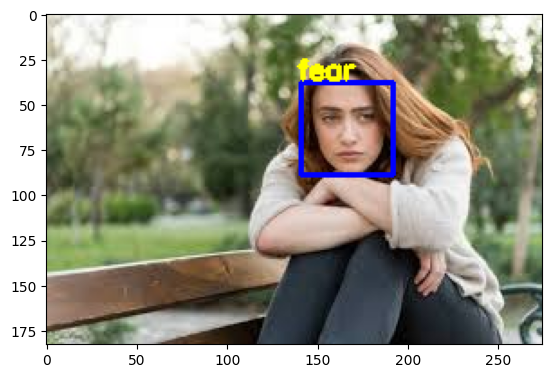

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


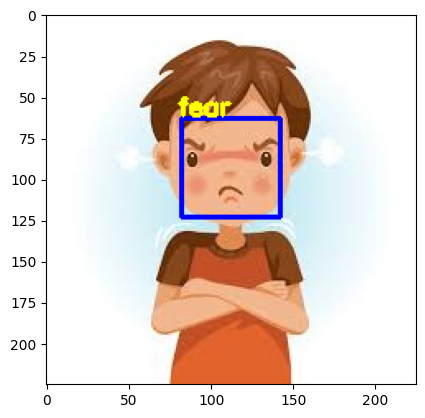

In [31]:
img="/content/Sad.jpeg"
image2emotion(img)
img="/content/angry.jpeg"
image2emotion(img)

 set the file path of the image you want to analyze.

 then apply the image2emotion(img) function to that image.

**About Output:**

The display shows the original image annotated with:

A colored rectangle around the detected face.

The name of the predicted emotion above the rectangle.

This visual feedback lets you quickly see if the emotion recognition is working.

In [32]:
new_model

<Functional name=functional, built=True>

In [33]:

# import dependencies
from IPython.display import display, Javascript, Image,clear_output
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

**IPython.display & google.colab.output:** For displaying images, running JavaScript, clearing outputs, and enabling interactive features in Colab.

**base64:** For encoding/decoding data (often with images).

**cv2 (OpenCV)**: For image processing and face detection.

**numpy, PIL, io, html, time:** For working with arrays, images, file streams, HTML content, and timing.

In [34]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

**1. js_to_image(js_reply)**

Converts a JavaScript object (which contains a webcam image as a base64 string) into an OpenCV (BGR) image in Python.

Decodes the base64 string, loads it into numpy, and then converts it to an OpenCV image.

**2. bbox_to_bytes(bbox_array)**

Takes a numpy array representing an image (like a bounding box to overlay), and converts it into a base64 string of a PNG image.

This base64 string can then be sent back to the frontend to overlay graphics on a video stream.

**In short:** The code enables two-way image exchange between JavaScript (frontend) and Python/OpenCV (backend), useful for live video processing and overlays.

In [35]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "Status:";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '' +
          'When finished, click here or on the video to stop this demo';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

This JavaScript code creates a live video stream from a webcam using the browser's media devices API. It dynamically adds a video element to the webpage, captures frames from the webcam feed into a canvas, and converts them to image data URLs for further processing or display. The setup includes controls to start and stop the stream, update status labels, and overlay images. The Python functions wrap and execute this JavaScript within an environment that supports in-browser scripting, enabling live video streaming and frame capture from Python code.

In [36]:

# Detecting the face and emotion prediction with the live webcam feed
def face_detect():
  import cv2
  from PIL import Image
  import numpy as np
  import os
  from keras.models import load_model
  from time import sleep
  from keras.preprocessing.image import img_to_array
  from keras.preprocessing import image
# start streaming video from webcam
  video_stream()
# label for video
  label_html = 'Capturing...'
# initialze bounding box to empty
  bbox = ''
  count = 0
  while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
      break

    # convert JS response to OpenCV Image
    frame = js_to_image(js_reply["img"])
    faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')
    # grayscale image for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
     # get face region coordinates
    faces = faceCascade.detectMultiScale(gray)
    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)
    # get face bounding box for overlay
    for x,y,w,h in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(0,255,0),2)
      roi_gray = gray[y:y+h,x:x+w]
      roi_gray = cv2.resize(roi_gray,(img_size,img_size))
      facess=faceCascade.detectMultiScale(roi_gray)
      if np.sum([roi_gray])!=0:
        roi_color=frame[y:y+h,x:x+w]
        final_image=cv2.resize(roi_color,(img_size,img_size))
        final_image=np.expand_dims(final_image,axis=0)
        final_image=final_image/255
        predict=new_model.predict(final_image)
        x1,y1,w1,h1=0,0,175,75
        label=Classes[np.argmax(predict)]
        label_position = (x,y)
        cv2.putText(bbox_array,label,label_position,cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
      else:
        cv2.putText(bbox_array,'No Faces',(30,80),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

This function uses our webcam feed to detect faces in real time and predict emotions for each face.

It starts the camera and reads frames continuously.

Converts each frame to grayscale and uses OpenCV’s Haar Cascade to find faces.

Draws a green rectangle (bounding box) around each detected face.

Crops and resizes the face, normalizes it, and feeds it into a pre-trained emotion model.

Displays the predicted emotion (like Happy or Sad) on the video.

Updates every frame so you get live mood detection.

In [37]:
# Detecting emotion via webcam
face_detect()

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


# **Conclusion**
**DeepFER – Facial Emotion Recognition with Deep Learning**

**1.** Dataset Setup
Mounts Google Drive (but later uses wget to download from Dropbox)

Downloads archive.zip containing a facial emotion dataset

Unzips into /content/train and /content/test

**Target classes:**

text
['sad', 'neutral', 'fear', 'happy', 'disgust', 'angry', 'surprise']

**2.** Data Preprocessing
Images are resized to 224×224×3 to match MobileNetV2 input

Uses OpenCV (cv2) for reading and resizing images

Creates (image_array, class_index) pairs

Shuffles the dataset and limits to 2,500 samples (for faster training)

Normalizes pixel values → X / 255.0

Converts labels to NumPy arrays

**3.**Transfer Learning with MobileNetV2
Loads MobileNetV2 with weights='imagenet', include_top=False

Freezes all base model layers (model.trainable = False)

**Base output is flattened and followed by:**

text
Dense(128) → ReLU
Dense(64)  → ReLU
Dense(7)   → Softmax
Creates new keras.Model(inputs=base_input, outputs=final_output)

**4.** Expected Next Steps (not fully shown in your snippet)
Compile the model:

python
new_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

**Train using**:

python
new_model.fit(X, y, validation_split=0.2, epochs=EPOCHS, batch_size=32)
Evaluate on test set

Save the model for later inference

Observations & Possible Improvements
Data Limiting –
Restricting to only 2,500 images will speed up training, but may hurt accuracy.

**We might:**

Gradually increase dataset size

Use data augmentation to create variety

**Augmentation** –
Using ImageDataGenerator or tf.keras.layers.Random* can improve generalization.

**Pooling Before Dense** –
Instead of Flatten() (which creates many parameters), GlobalAveragePooling2D() is more common with MobileNetV2 (fewer parameters, less overfitting).

**Class Imbalance** –
Your class counts show imbalance ('disgust' has very few samples). Consider:

**Class**-weighted loss

Oversampling minority classes

**Fine-tuning** –
After initial training, unfreeze top MobileNetV2 layers and